# Customer Churn em Telecom — IBM Telco Customer Churn

## Projeto end-to-end: negócio → dados → modelagem → explicabilidade → API

Este notebook foi construído para ser **didático e reproduzível**. O foco é entender cada etapa do problema antes de chegar ao deploy.

**Fonte de referência da base:**
https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset

O arquivo utilizado já está incluído no projeto em `data/raw/Telco_customer_churn.xlsx`, portanto **não é necessário baixar a base pela internet para executar o notebook**.

## 1. Problema de negócio

Uma operadora de telecom quer identificar clientes com maior risco de cancelar seus serviços (**churn**).

O objetivo do modelo é estimar, para cada cliente:

- a **probabilidade de churn**;
- uma previsão binária: `0 = Não Churn` e `1 = Churn`;
- uma faixa simples de risco para facilitar o consumo pelo negócio.

A probabilidade pode apoiar ações de retenção, priorização de campanhas e análise de perfis mais propensos à saída.

> Importante: o modelo estima risco; a decisão comercial de oferecer ou não uma ação de retenção deve ser uma camada separada de política.

## 2. Pergunta analítica

> **Com base nas características do cliente, produtos contratados, relacionamento e cobrança, qual é a probabilidade de esse cliente apresentar churn?**

É um problema de **classificação binária supervisionada**.

## 3. Fonte e estrutura da base

- **Base:** Telco Customer Churn — IBM
- **Referência:** https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset
- **Arquivo deste projeto:** `data/raw/Telco_customer_churn.xlsx`
- **Registros:** 7.043 clientes
- **Colunas:** 33
- **Target:** `Churn Value`
- **0:** Não Churn
- **1:** Churn

A planilha possui campos adicionais, como localização e informações associadas ao próprio churn. Nem todas as 33 colunas devem entrar no modelo.

## 4. Dicionário de dados — visão de negócio

### Identificação e localização — **não usadas no modelo**
| Variável | Interpretação |
|---|---|
| CustomerID | Identificador único do cliente |
| Country / State / City / Zip Code | Localização |
| Lat Long / Latitude / Longitude | Coordenadas geográficas |
| Count | Contador do registro |

### Perfil e relacionamento
| Variável | Interpretação |
|---|---|
| Gender | Gênero |
| Senior Citizen | Indica cliente idoso |
| Partner | Possui parceiro(a) |
| Dependents | Possui dependentes |
| Tenure Months | Meses de relacionamento com a operadora |

### Serviços contratados
| Variável | Interpretação |
|---|---|
| Phone Service | Serviço de telefonia |
| Multiple Lines | Múltiplas linhas |
| Internet Service | Tipo de internet |
| Online Security | Segurança online |
| Online Backup | Backup online |
| Device Protection | Proteção do dispositivo |
| Tech Support | Suporte técnico |
| Streaming TV | Streaming de TV |
| Streaming Movies | Streaming de filmes |

### Contrato e cobrança
| Variável | Interpretação |
|---|---|
| Contract | Tipo de contrato |
| Paperless Billing | Fatura digital |
| Payment Method | Forma de pagamento |
| Monthly Charges | Cobrança mensal |
| Total Charges | Cobrança acumulada |

### Target e campos excluídos por risco de leakage
| Variável | Uso |
|---|---|
| Churn Label | Duplicação textual do target — excluir |
| Churn Value | **Target**: 0/1 |
| Churn Score | Score já relacionado ao churn — excluir |
| Churn Reason | Motivo do churn, conhecido depois do evento — excluir |
| CLTV | Campo derivado/analítico; excluído para manter o exercício simples e evitar ambiguidades temporais |

## 5. Preparação do ambiente

A célula abaixo verifica as bibliotecas necessárias e instala apenas as que estiverem faltando no mesmo ambiente do kernel.

In [1]:
import sys, subprocess, importlib.util

packages = {
    "pandas": "pandas", "numpy": "numpy", "matplotlib": "matplotlib",
    "sklearn": "scikit-learn", "lightgbm": "lightgbm", "xgboost": "xgboost",
    "shap": "shap", "joblib": "joblib", "openpyxl": "openpyxl"
}
missing = [pip_name for module, pip_name in packages.items() if importlib.util.find_spec(module) is None]
if missing:
    print("Instalando bibliotecas ausentes:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("Ambiente pronto: todas as bibliotecas principais já estão instaladas.")

Ambiente pronto: todas as bibliotecas principais já estão instaladas.


## 6. Importações e configurações

Aqui concentramos as bibliotecas usadas no notebook. Isso facilita a leitura e evita imports espalhados.

In [2]:
from pathlib import Path
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42

## 7. Leitura da base — da forma mais simples possível

Como o Excel já está dentro do projeto, não precisamos de API, Kaggle API ou download externo.

A célula procura o arquivo funcionando tanto quando o notebook é aberto a partir da pasta raiz quanto a partir de `notebooks/`.

In [3]:
candidates = [
    Path("data/raw/Telco_customer_churn.xlsx"),
    Path("../data/raw/Telco_customer_churn.xlsx"),
]

DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Não encontrei data/raw/Telco_customer_churn.xlsx")

df = pd.read_excel(DATA_PATH)

# A coluna vem como object porque existem algumas células vazias.
# Convertendo para número, valores inválidos tornam-se NaN e serão tratados depois.
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

print(f"Arquivo: {DATA_PATH}")
print(f"Dimensão: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
display(df.head())

Arquivo: ..\data\raw\Telco_customer_churn.xlsx
Dimensão: 7,043 linhas x 33 colunas


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


## 8. Validação estrutural

Antes da EDA, confirmamos que o arquivo é realmente o esperado. Diferentemente de um `assert` sem mensagem, esta validação informa exatamente o que estaria faltando.

In [4]:
TARGET = "Churn Value"
FEATURES = [
    "Gender", "Senior Citizen", "Partner", "Dependents", "Tenure Months",
    "Phone Service", "Multiple Lines", "Internet Service", "Online Security",
    "Online Backup", "Device Protection", "Tech Support", "Streaming TV",
    "Streaming Movies", "Contract", "Paperless Billing", "Payment Method",
    "Monthly Charges", "Total Charges"
]

required = FEATURES + [TARGET]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Colunas esperadas ausentes: {missing}")

print("Estrutura validada com sucesso.")
print("Target:", TARGET)
print("Features utilizadas:", len(FEATURES))

Estrutura validada com sucesso.
Target: Churn Value
Features utilizadas: 19


## 9. Primeira leitura dos dados

Agora observamos tipos, estatísticas gerais e a distribuição do target. Essa etapa serve para entender a base antes de qualquer transformação.

In [6]:
# Identifica automaticamente features quantitativas
quantitative_features = (
    df[FEATURES]
    .select_dtypes(include="number")
    .columns
    .tolist()
)

print("Features quantitativas:")
print(quantitative_features)

print("\nResumo estatístico:")
display(
    df[quantitative_features]
    .describe()
    .T
)

print("\nDistribuição do target:")
display(
    df[TARGET]
    .value_counts()
    .rename(index={0: "Não Churn", 1: "Churn"})
    .to_frame("clientes")
)

churn_rate = df[TARGET].mean()

print(f"\nChurn rate: {churn_rate:.2%}")

Features quantitativas:
['Tenure Months', 'Monthly Charges', 'Total Charges']

Resumo estatístico:


,count,mean,std,min,25%,50%,75%,max
Tenure Months,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
Monthly Charges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
Total Charges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80



Distribuição do target:


,clientes
Churn Value,
Não Churn,5174
Churn,1869



Churn rate: 26.54%


## 10. Qualidade de dados

### 10.1 Duplicidades

Primeiro verificamos duplicatas exatas. Se existirem, serão removidas **antes** do split, evitando que o mesmo registro possa aparecer em treino e teste.

In [7]:
n_dup = df.duplicated().sum()
print(f"Linhas totalmente duplicadas: {n_dup}")

if n_dup > 0:
    before = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicatas removidas: {before - len(df)}")
else:
    print("Nenhuma duplicata exata precisa ser removida.")

Linhas totalmente duplicadas: 0
Nenhuma duplicata exata precisa ser removida.


### 10.2 Missing values

Mostramos os missing das variáveis usadas pelo modelo. `Total Charges` possui alguns valores vazios; não eliminaremos clientes por isso. O pipeline fará imputação pela mediana.

In [8]:
missing_table = df[FEATURES + [TARGET]].isna().sum().sort_values(ascending=False).to_frame("missing")
missing_table["pct"] = missing_table["missing"] / len(df)
display(missing_table[missing_table["missing"] > 0])

,missing,pct
Total Charges,11,0.001562


### 10.3 Outliers

Outlier não significa automaticamente erro. Em telecom, clientes com charges ou tenure altos podem ser perfeitamente legítimos.

Usaremos IQR apenas para **identificar** valores extremos; não removeremos automaticamente observações válidas.

In [9]:
numeric_features = ["Tenure Months", "Monthly Charges", "Total Charges"]
rows=[]
for col in numeric_features:
    q1, q3 = df[col].quantile([0.25,0.75])
    iqr=q3-q1
    low, high=q1-1.5*iqr, q3+1.5*iqr
    count=((df[col] < low) | (df[col] > high)).sum()
    rows.append([col,q1,q3,low,high,int(count)])
outlier_table=pd.DataFrame(rows,columns=["variável","Q1","Q3","limite_inferior","limite_superior","qtd_outliers_IQR"])
display(outlier_table)

,variável,Q1,Q3,limite_inferior,limite_superior,qtd_outliers_IQR
0,Tenure Months,9.00,55.0000,-60.00000,124.00000,0
1,Monthly Charges,35.50,89.8500,-46.02500,171.37500,0
2,Total Charges,401.45,3794.7375,-4688.48125,8884.66875,0


## 11. Análise Exploratória de Dados (EDA) orientada ao negócio

A ideia é responder perguntas simples antes de modelar: churn é maior em contratos mensais? Clientes com menor tenure apresentam mais churn? Há diferença por serviço de internet?

In [10]:
def churn_by(category):
    out=(df.groupby(category)[TARGET].agg(clientes="size", churn_rate="mean")
           .sort_values("churn_rate",ascending=False))
    out["churn_rate"]=(out["churn_rate"]*100).round(1)
    return out

print("Churn por tipo de contrato")
display(churn_by("Contract"))
print("Churn por serviço de internet")
display(churn_by("Internet Service"))
print("Churn por método de pagamento")
display(churn_by("Payment Method"))

Churn por tipo de contrato


,clientes,churn_rate
Contract,,
Month-to-month,3875,42.7
One year,1473,11.3
Two year,1695,2.8


Churn por serviço de internet


,clientes,churn_rate
Internet Service,,
Fiber optic,3096,41.9
DSL,2421,19.0
No,1526,7.4


Churn por método de pagamento


,clientes,churn_rate
Payment Method,,
Electronic check,2365,45.3
Mailed check,1612,19.1
Bank transfer (automatic),1544,16.7
Credit card (automatic),1522,15.2


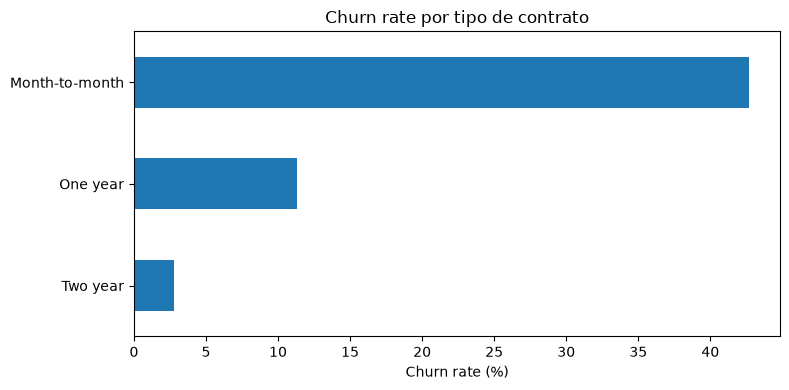

In [11]:
# Churn rate por contrato em formato gráfico
tmp=churn_by("Contract").sort_values("churn_rate")
ax=tmp["churn_rate"].plot(kind="barh",figsize=(8,4),title="Churn rate por tipo de contrato")
ax.set_xlabel("Churn rate (%)"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

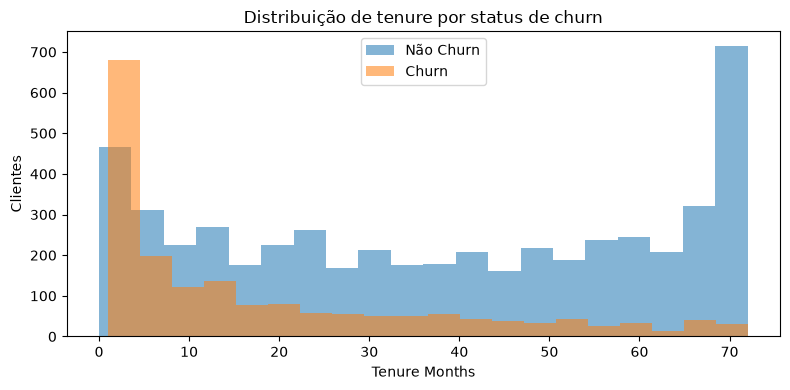

In [12]:
# Tenure: comparação da distribuição para churn x não churn
fig, ax = plt.subplots(figsize=(8,4))
for value,label in [(0,"Não Churn"),(1,"Churn")]:
    ax.hist(df.loc[df[TARGET]==value,"Tenure Months"], bins=20, alpha=0.55, label=label)
ax.set_title("Distribuição de tenure por status de churn")
ax.set_xlabel("Tenure Months"); ax.set_ylabel("Clientes"); ax.legend(); plt.tight_layout(); plt.show()

## 12. Variáveis excluídas e prevenção de leakage

Não entram no modelo:

- identificadores (`CustomerID`);
- geografia detalhada;
- `Churn Label`, pois replica o target;
- `Churn Score`, pois já é um score associado ao churn;
- `Churn Reason`, que só faz sentido após/concomitantemente ao evento;
- `CLTV`, para manter o exercício simples e evitar misturar um indicador derivado com as features operacionais.

Essa separação é tão importante quanto escolher o algoritmo.

## 13. Separação treino e teste

O teste ficará isolado para avaliação final. `stratify=y` preserva aproximadamente a proporção de churn nas duas amostras.

In [13]:
X = df[FEATURES].copy()
y = df[TARGET].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("Treino:",X_train.shape,"| churn:",f"{y_train.mean():.2%}")
print("Teste :",X_test.shape,"| churn:",f"{y_test.mean():.2%}")

Treino: (5634, 19) | churn: 26.54%
Teste : (1409, 19) | churn: 26.54%


## 14. Pré-processamento em Pipeline

- Numéricas: imputação pela mediana + padronização.
- Categóricas: imputação pela moda + One-Hot Encoding.

O pipeline garante que o mesmo tratamento aprendido no treino seja aplicado no teste e futuramente na API.

In [14]:
categorical_features = [c for c in FEATURES if c not in numeric_features]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),
], verbose_feature_names_out=False)

## 15. Métricas de avaliação

Usaremos:

- **AUC**: capacidade de ordenação entre churn e não churn;
- **KS**: maior separação entre as distribuições acumuladas das duas classes;
- **Recall / Sensibilidade**: quanto dos churners foi identificado;
- **Especificidade**: quanto dos não churners foi corretamente preservado;
- **Precision**: entre os previstos como churn, quantos realmente são churn;
- **F1**: equilíbrio entre precision e recall;
- **Accuracy**: proporção total de acertos.

Para métricas de classe, começaremos com cutoff 0,50 apenas como referência.

In [15]:
def ks_statistic(y_true, proba):
    fpr, tpr, _ = roc_curve(y_true, proba)
    return float(np.max(tpr - fpr))

def classification_metrics(y_true, proba, cutoff=0.50):
    pred=(proba >= cutoff).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true,pred).ravel()
    specificity = tn/(tn+fp) if (tn+fp)>0 else 0
    return {
        "AUC": roc_auc_score(y_true,proba),
        "KS": ks_statistic(y_true,proba),
        "Accuracy": accuracy_score(y_true,pred),
        "Precision": precision_score(y_true,pred,zero_division=0),
        "Recall_Sensitivity": recall_score(y_true,pred,zero_division=0),
        "Specificity": specificity,
        "F1": f1_score(y_true,pred,zero_division=0),
    }

## 16. Cinco modelos candidatos

Compararemos modelos com níveis diferentes de complexidade:

1. Regressão Logística — baseline interpretável;
2. Árvore de Classificação;
3. Random Forest;
4. LightGBM;
5. XGBoost.

In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=250, max_depth=8, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=1),
    "LightGBM": LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=31, random_state=RANDOM_STATE, verbosity=-1, n_jobs=1),
    "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, subsample=0.9, colsample_bytree=0.9, random_state=RANDOM_STATE, n_jobs=1, eval_metric="logloss"),
}

fitted_models={}
rows=[]
for name,model in models.items():
    pipe=Pipeline([("preprocessor",preprocessor),("model",model)])
    pipe.fit(X_train,y_train)
    fitted_models[name]=pipe
    for split,Xs,ys in [("Treino",X_train,y_train),("Teste",X_test,y_test)]:
        p=pipe.predict_proba(Xs)[:,1]
        rows.append({"Modelo":name,"Amostra":split,**classification_metrics(ys,p,0.50)})
results=pd.DataFrame(rows)
display(results.round(4))

,Modelo,Amostra,AUC,KS,Accuracy,Precision,Recall_Sensitivity,Specificity,F1
0,Logistic Regression,Treino,0.8623,0.5679,0.8140,0.6705,0.5880,0.8956,0.6265
1,Logistic Regression,Teste,0.8487,0.5305,0.8020,0.6435,0.5695,0.8860,0.6043
2,Decision Tree,Treino,0.8606,0.5711,0.8064,0.6405,0.6161,0.8751,0.6280
3,Decision Tree,Teste,0.8357,0.5020,0.7942,0.6160,0.5963,0.8657,0.6060
4,Random Forest,Treino,0.9006,0.6472,0.8303,0.7282,0.5753,0.9224,0.6428
5,Random Forest,Teste,0.8552,0.5593,0.8105,0.6801,0.5401,0.9082,0.6021
6,LightGBM,Treino,0.9569,0.7882,0.8860,0.8148,0.7385,0.9394,0.7747
7,LightGBM,Teste,0.8460,0.5489,0.7977,0.6344,0.5615,0.8831,0.5957
8,XGBoost,Treino,0.9061,0.6537,0.8401,0.7339,0.6234,0.9183,0.6741
9,XGBoost,Teste,0.8561,0.5472,0.8013,0.6487,0.5481,0.8928,0.5942


## 17. Overfitting — comparação treino × teste

Diferenças muito grandes entre AUC/KS de treino e teste podem indicar sobreajuste. A tabela abaixo deixa esse gap explícito.

In [17]:
pivot_auc=results.pivot(index="Modelo",columns="Amostra",values="AUC")
pivot_auc["Gap_AUC_Treino_menos_Teste"]=pivot_auc["Treino"]-pivot_auc["Teste"]
display(pivot_auc.sort_values("Teste",ascending=False).round(4))

Amostra,Teste,Treino,Gap_AUC_Treino_menos_Teste
Modelo,,,
XGBoost,0.8561,0.9061,0.0500
Random Forest,0.8552,0.9006,0.0453
Logistic Regression,0.8487,0.8623,0.0136
LightGBM,0.8460,0.9569,0.1109
Decision Tree,0.8357,0.8606,0.0249


## 18. Curvas ROC dos cinco modelos

A curva ROC mostra o trade-off entre taxa de verdadeiros positivos e falsos positivos em todos os cutoffs.

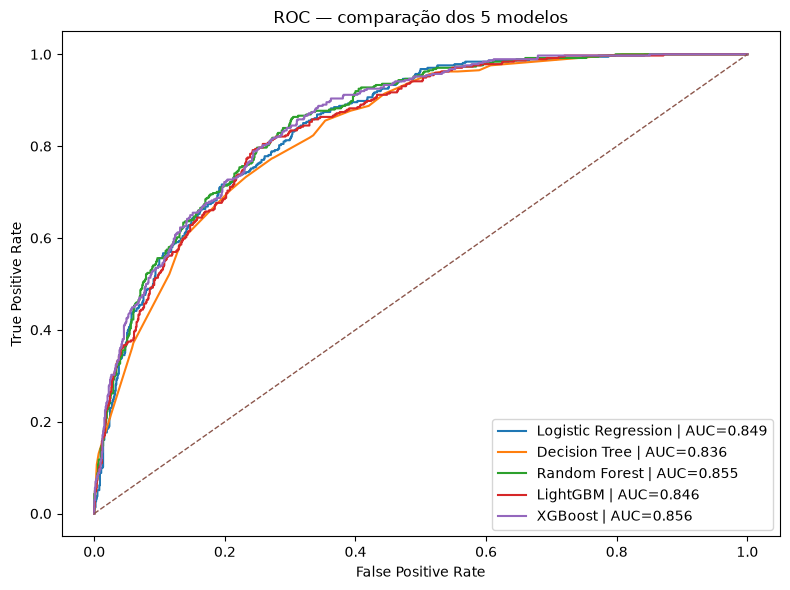

In [18]:
plt.figure(figsize=(8,6))
for name,pipe in fitted_models.items():
    p=pipe.predict_proba(X_test)[:,1]
    fpr,tpr,_=roc_curve(y_test,p)
    plt.plot(fpr,tpr,label=f"{name} | AUC={roc_auc_score(y_test,p):.3f}")
plt.plot([0,1],[0,1],'--',linewidth=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC — comparação dos 5 modelos"); plt.legend(); plt.tight_layout(); plt.show()

## 19. Matrizes de confusão — cutoff 0,50

Cada matriz mostra TN, FP, FN e TP. Mantemos uma figura por modelo para facilitar a leitura.

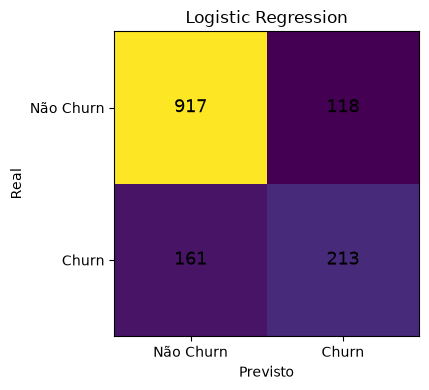

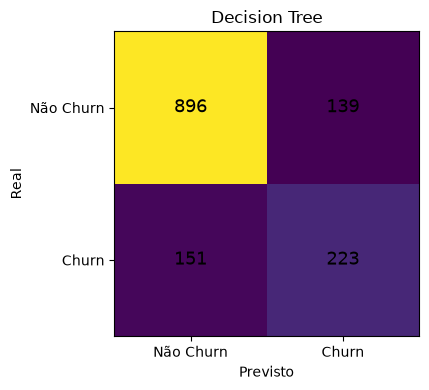

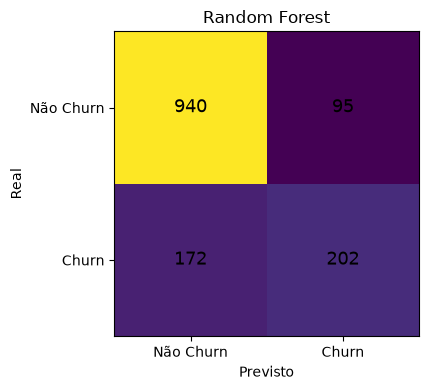

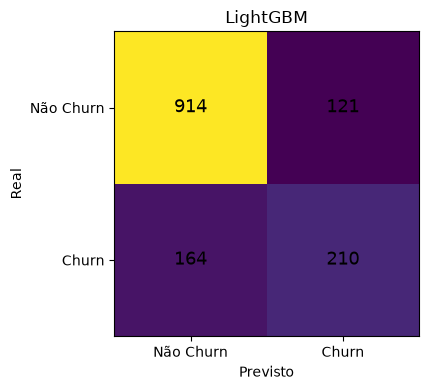

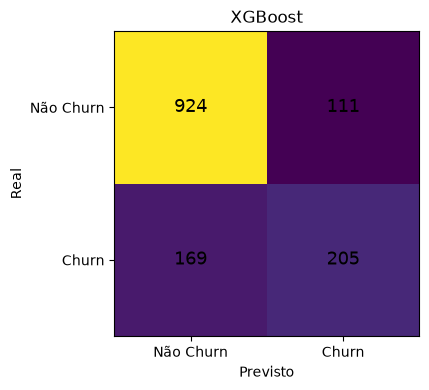

In [19]:
for name,pipe in fitted_models.items():
    p=pipe.predict_proba(X_test)[:,1]
    pred=(p>=0.50).astype(int)
    cm=confusion_matrix(y_test,pred)
    fig,ax=plt.subplots(figsize=(4.5,4))
    im=ax.imshow(cm)
    for (i,j),v in np.ndenumerate(cm): ax.text(j,i,str(v),ha='center',va='center',fontsize=13)
    ax.set_xticks([0,1],labels=["Não Churn","Churn"]); ax.set_yticks([0,1],labels=["Não Churn","Churn"])
    ax.set_xlabel("Previsto"); ax.set_ylabel("Real"); ax.set_title(name); plt.tight_layout(); plt.show()

## 20. Grid Search — tuning simples e controlado

Usaremos grids pequenos para manter o código e o tempo de execução didáticos. A otimização usa **AUC em validação cruzada**, sem escolher hiperparâmetros pelo teste.

In [20]:
param_grids = {
    # Poucas combinações de propósito: o objetivo aqui é ensinar Grid Search
    # sem transformar o notebook em um processo demorado de tuning.
    "Logistic Regression": {
        "model__C": [0.3, 1.0]
    },
    "Decision Tree": {
        "model__max_depth": [4, 7],
        "model__min_samples_leaf": [10]
    },
    "Random Forest": {
        "model__n_estimators": [150],
        "model__max_depth": [6, 10],
        "model__min_samples_leaf": [5]
    },
    "LightGBM": {
        "model__n_estimators": [100, 180],
        "model__learning_rate": [0.05],
        "model__num_leaves": [15, 31]
    },
    "XGBoost": {
        "model__n_estimators": [120],
        "model__learning_rate": [0.05, 0.10],
        "model__max_depth": [3, 5]
    },
}

# 3 folds é suficiente para o caráter didático do exercício e reduz
# bastante o tempo de processamento em comparação com 5 folds.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

searches = {}
tuned_rows = []

for name, model in models.items():
    print(f"Tuning: {name}")

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[name],
        scoring="roc_auc",
        cv=cv,
        n_jobs=1,              # evita paralelismo excessivo / travamento do kernel
        return_train_score=True
    )

    gs.fit(X_train, y_train)
    searches[name] = gs

    tuned_rows.append({
        "Modelo": name,
        "CV_AUC": gs.best_score_,
        "Melhores parâmetros": gs.best_params_
    })

tuned_summary = (
    pd.DataFrame(tuned_rows)
      .sort_values("CV_AUC", ascending=False)
      .reset_index(drop=True)
)

display(tuned_summary)

Tuning: Logistic Regression
Tuning: Decision Tree
Tuning: Random Forest
Tuning: LightGBM
Tuning: XGBoost


,Modelo,CV_AUC,Melhores parâmetros
0,XGBoost,0.865021,"{'model__learning_rate': 0.05, 'model__max_dep..."
1,LightGBM,0.861445,"{'model__learning_rate': 0.05, 'model__n_estim..."
2,Random Forest,0.860437,"{'model__max_depth': 10, 'model__min_samples_l..."
3,Logistic Regression,0.858708,{'model__C': 1.0}
4,Decision Tree,0.840677,"{'model__max_depth': 4, 'model__min_samples_le..."


## 21. Escolha do melhor modelo

O vencedor é escolhido pela AUC média de validação cruzada no conjunto de treino. O conjunto de teste continua sem participar da decisão.

In [21]:
best_name=tuned_summary.iloc[0]["Modelo"]
best_model=searches[best_name].best_estimator_
print("Modelo selecionado:",best_name)
print("CV AUC:",f"{searches[best_name].best_score_:.4f}")
print("Parâmetros:",searches[best_name].best_params_)

Modelo selecionado: XGBoost
CV AUC: 0.8650
Parâmetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 120}


## 22. Definição do cutoff por KS / Youden usando OOF

Em vez de usar 0,50 automaticamente, geramos probabilidades **out-of-fold (OOF)** somente no treino e escolhemos o ponto que maximiza `TPR - FPR`, equivalente ao máximo KS na curva ROC.

In [22]:
oof_proba=cross_val_predict(best_model,X_train,y_train,cv=cv,method="predict_proba",n_jobs=1)[:,1]
fpr,tpr,thresholds=roc_curve(y_train,oof_proba)
ks_values=tpr-fpr
best_idx=int(np.argmax(ks_values))
optimal_cutoff=float(thresholds[best_idx])
print(f"Cutoff escolhido: {optimal_cutoff:.4f}")
print(f"KS OOF no ponto: {ks_values[best_idx]:.4f}")

Cutoff escolhido: 0.2396
KS OOF no ponto: 0.5691


## 23. Avaliação final no teste

Somente agora usamos o teste para medir a performance final do modelo e do cutoff já definidos.

,AUC,KS,Accuracy,Precision,Recall_Sensitivity,Specificity,F1
XGBoost,0.8559,0.5399,0.7402,0.5066,0.8262,0.7092,0.628


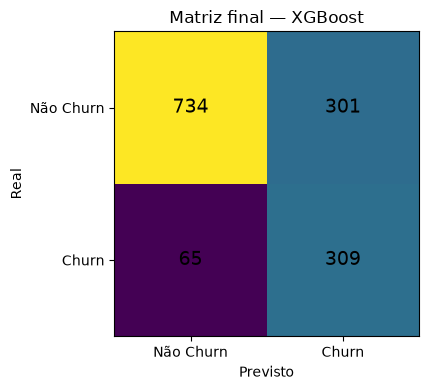

In [23]:
best_model.fit(X_train,y_train)
test_proba=best_model.predict_proba(X_test)[:,1]
final_metrics=classification_metrics(y_test,test_proba,optimal_cutoff)
display(pd.DataFrame([final_metrics],index=[best_name]).round(4))

final_pred=(test_proba>=optimal_cutoff).astype(int)
cm=confusion_matrix(y_test,final_pred)
fig,ax=plt.subplots(figsize=(5,4)); ax.imshow(cm)
for (i,j),v in np.ndenumerate(cm): ax.text(j,i,str(v),ha='center',va='center',fontsize=14)
ax.set_xticks([0,1],labels=["Não Churn","Churn"]); ax.set_yticks([0,1],labels=["Não Churn","Churn"])
ax.set_xlabel("Previsto"); ax.set_ylabel("Real"); ax.set_title(f"Matriz final — {best_name}"); plt.tight_layout(); plt.show()

## 24. Faixas de risco

Para facilitar a leitura de negócio, criamos faixas didáticas de probabilidade. Elas **não são uma política universal**; em produção, deveriam ser definidas com base em capacidade de retenção, custo da ação e valor esperado do cliente.

In [24]:
def risk_band(prob):
    if prob < 0.10: return "A", "Risco Muito Baixo"
    if prob < 0.25: return "B", "Risco Baixo"
    if prob < 0.50: return "C", "Risco Médio"
    if prob < 0.75: return "D", "Risco Alto"
    return "E", "Risco Muito Alto"

example=pd.DataFrame({"probabilidade":[0.05,0.18,0.38,0.62,0.84]})
example[["grade","classe"]]=example["probabilidade"].apply(lambda p: pd.Series(risk_band(p)))
display(example)

,probabilidade,grade,classe
0,0.05,A,Risco Muito Baixo
1,0.18,B,Risco Baixo
2,0.38,C,Risco Médio
3,0.62,D,Risco Alto
4,0.84,E,Risco Muito Alto


## 25. SHAP — explicando modelos de caixa preta

Para modelos baseados em árvores, SHAP ajuda a entender quais variáveis mais influenciam as previsões.

Para manter a execução leve, usamos uma amostra do teste e o modelo de árvore tunado quando o vencedor for Random Forest, LightGBM ou XGBoost.

Importância das variáveis via SHAP — XGBoost


,Variável,Importância_SHAP
0,Contract_Month-to-month,0.639960
1,Tenure Months,0.498301
2,Dependents_No,0.439040
3,Monthly Charges,0.209939
4,Online Security_No,0.200517
5,Internet Service_Fiber optic,0.177462
6,Tech Support_No,0.167004
7,Payment Method_Electronic check,0.161640
8,Contract_Two year,0.139593
9,Paperless Billing_No,0.097067


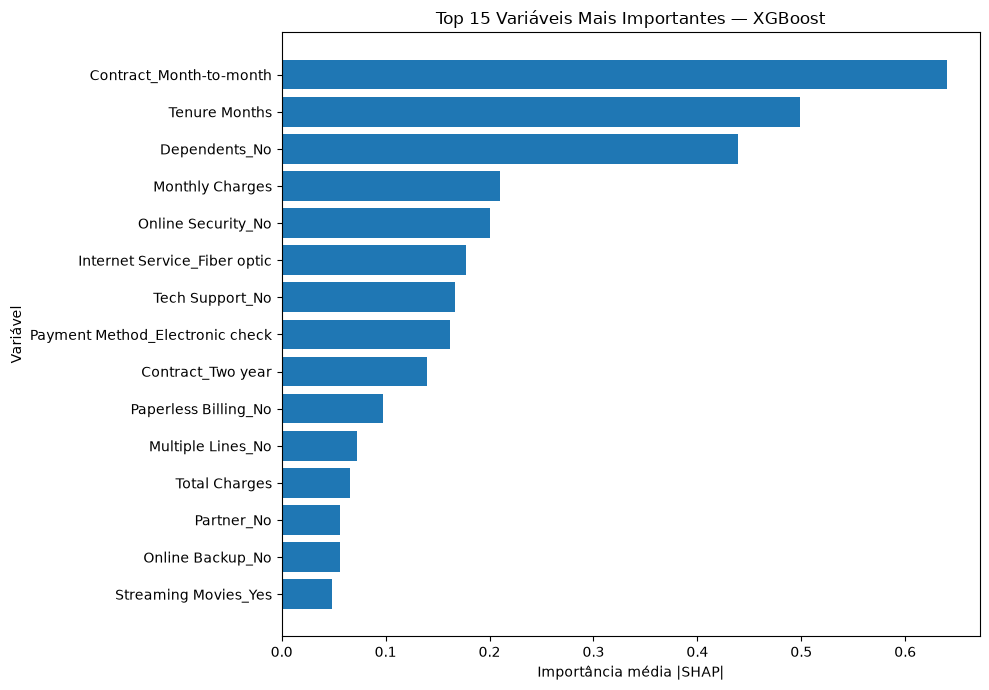

In [29]:
# ============================================================
# IMPORTÂNCIA GLOBAL DAS VARIÁVEIS VIA SHAP
# ============================================================
#
# Este gráfico mostra a importância global das variáveis
# usando a média do valor absoluto dos SHAP values.
#
# Quanto maior o mean(|SHAP|), maior a influência média
# da variável nas previsões do modelo.
# ============================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Verifica se o melhor modelo é baseado em árvores
# ------------------------------------------------------------

if best_name in {"Random Forest", "LightGBM", "XGBoost"}:

    # Recupera o pré-processador e o modelo já treinados
    preprocessor_shap = best_model.named_steps["preprocessor"]
    model_shap = best_model.named_steps["model"]

    # --------------------------------------------------------
    # 2. Usa uma amostra da base de teste
    #
    # Isso deixa o cálculo do SHAP mais rápido.
    # --------------------------------------------------------

    X_shap = X_test.sample(
        n=min(500, len(X_test)),
        random_state=RANDOM_STATE
    )

    # --------------------------------------------------------
    # 3. Aplica o mesmo pré-processamento usado no treinamento
    # --------------------------------------------------------

    X_shap_transformed = preprocessor_shap.transform(X_shap)

    # Recupera os nomes das variáveis após One-Hot Encoding
    feature_names = preprocessor_shap.get_feature_names_out()

    # --------------------------------------------------------
    # 4. Calcula os SHAP values
    # --------------------------------------------------------

    explainer = shap.TreeExplainer(model_shap)

    shap_values = explainer.shap_values(
        X_shap_transformed
    )

    # --------------------------------------------------------
    # 5. Trata diferentes formatos retornados pelo SHAP
    #
    # Dependendo do modelo/versão, o SHAP pode retornar:
    #
    # (linhas, variáveis)
    #
    # ou
    #
    # (linhas, variáveis, classes)
    # --------------------------------------------------------

    shap_array = np.asarray(shap_values)

    if shap_array.ndim == 3:
        # Para classificação binária,
        # selecionamos os SHAP values da classe 1 = Churn
        shap_array = shap_array[:, :, 1]

    # --------------------------------------------------------
    # 6. Calcula importância global:
    #
    # média do valor absoluto do SHAP por variável
    # --------------------------------------------------------

    shap_importance = pd.DataFrame({
        "Variável": feature_names,
        "Importância_SHAP": np.abs(shap_array).mean(axis=0)
    })

    # Ordena da mais importante para a menos importante
    shap_importance = (
        shap_importance
        .sort_values(
            "Importância_SHAP",
            ascending=False
        )
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # 7. Exibe tabela das 15 variáveis mais importantes
    # --------------------------------------------------------

    print(
        f"Importância das variáveis via SHAP — {best_name}"
    )

    display(
        shap_importance.head(15)
    )

    # --------------------------------------------------------
    # 8. Gráfico horizontal
    # --------------------------------------------------------

    top_n = 15

    plot_data = (
        shap_importance
        .head(top_n)
        .sort_values("Importância_SHAP")
    )

    plt.figure(figsize=(10, 7))

    plt.barh(
        plot_data["Variável"],
        plot_data["Importância_SHAP"]
    )

    plt.xlabel("Importância média |SHAP|")
    plt.ylabel("Variável")

    plt.title(
        f"Top {top_n} Variáveis Mais Importantes — {best_name}"
    )

    plt.tight_layout()
    plt.show()

else:

    print(
        f"O modelo selecionado foi {best_name}. "
        "Este bloco foi preparado para Random Forest, "
        "LightGBM ou XGBoost."
    )

## 26. Persistência do modelo com Joblib

Agora o modelo deixa de depender do notebook. Salvaremos **pipeline + cutoff + metadados** em um único artefato `.joblib`. Esse arquivo será carregado posteriormente pela API.

In [31]:
artifact={
    "pipeline":best_model,
    "cutoff":optimal_cutoff,
    "features":FEATURES,
    "model_name":best_name,
    "model_version":"1.0",
}

artifact_candidates=[Path("artifacts/telecom_churn_model.joblib"),Path("../artifacts/telecom_churn_model.joblib")]
ARTIFACT_PATH=artifact_candidates[0] if artifact_candidates[0].parent.exists() else artifact_candidates[1]
ARTIFACT_PATH.parent.mkdir(parents=True,exist_ok=True)
joblib.dump(artifact,ARTIFACT_PATH)
print("Modelo salvo em:",ARTIFACT_PATH)

Modelo salvo em: ..\artifacts\telecom_churn_model.joblib


## 27. Teste do artefato salvo

Antes de falar de API, verificamos que o objeto salvo pode ser recarregado e produzir previsão sem depender das variáveis que ficaram na memória do treinamento.

In [ ]:
    loaded=joblib.load(ARTIFACT_PATH)
    sample=X_test.iloc[[0]].copy()
    p=float(loaded["pipeline"].predict_proba(sample)[0,1])
    pred=int(p>=loaded["cutoff"])
    print(f"Probabilidade: {p:.2%}")
    print("Prediction:",pred,"-", "Churn" if pred else "Não Churn")
    print("Faixa:",risk_band(p))

Probabilidade: 5.57%
Prediction: 0 - Não Churn
Faixa: ('A', 'Risco Muito Baixo')


# PARTE II — Consumo do modelo por API

Até aqui todo o trabalho foi de **negócio, dados e modelagem**. Somente agora que o modelo está treinado e persistido entramos em deployment.

A ideia é separar:

`Treinamento → arquivo .joblib → FastAPI → endereço web → outros sistemas/pessoas`

## 28. O que a API fará

A API receberá as 19 features em JSON, carregará o pipeline salvo e devolverá:

- `churn_probability`;
- `prediction`: 0 ou 1;
- `prediction_label`: Não Churn ou Churn;
- cutoff usado;
- grade e classe de risco;
- versão do modelo.

A implementação está em `app/main.py`.

## 29. Executando localmente

No terminal, na raiz do projeto:

```bash
python -m src.train
uvicorn app.main:app --reload
```

Acesse:

- `http://127.0.0.1:8000/` — página inicial;
- `http://127.0.0.1:8000/docs` — Swagger interativo;
- `http://127.0.0.1:8000/redoc` — documentação alternativa;
- `http://127.0.0.1:8000/health` — status.

## 30. Deploy público

O projeto contém `render.yaml`. Depois de publicar o repositório no GitHub, o Render pode instalar as dependências, treinar/carregar o artefato e iniciar o FastAPI.

Veja `docs/DEPLOY_RENDER.md`.

Assim o consumidor não precisa do seu VS Code nem deste notebook: ele chama um endereço web.

## 31. Resumo do projeto

Neste exercício percorremos:

**Problema de negócio → entendimento da base → qualidade → EDA → prevenção de leakage → treino/teste → 5 modelos → métricas → overfitting → ROC → matrizes de confusão → Grid Search → escolha por CV → cutoff OOF/KS → teste final → SHAP → Joblib → FastAPI → deploy.**

A principal fonte de referência do dataset permanece documentada no notebook:
https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset